# 03 · Comprehensive EDA — Respiratory ER Demand

Statistical audit of the target variable **before** it reaches HDBSCAN (spatial clustering)
and the Temporal Fusion Transformer. The goal is not description for its own sake: every
section below answers a question that changes how the data must be fed to a model.

| § | Question | Why the model cares |
|---|---|---|
| 1 | Is the panel complete and internally consistent? | Gaps and identities become silent leakage |
| 2 | How skewed / heavy-tailed is the target? | Gradient-based learners converge badly on long right tails |
| 3 | How far from Gaussian is it, really? | Decides whether a transform is needed at all |
| 4 | Which transform actually works best? | The chosen transform is applied to every prediction and inverted at serving |
| 5 | How do variables co-move? | Redundant covariates waste TFT attention capacity |
| 6 | Is there multicollinearity? | Perfect collinearity makes attribution meaningless |

**Memory strategy.** The raw ER records exceed RAM, so aggregation happens in DuckDB
(out-of-core, straight off Parquet) and only the daily panel is materialised in pandas.

## 0 · Setup — the canonical target

The target definition is imported from `src/data/make_dataset.py`, not rewritten here.

> **Correction applied.** Earlier versions of this notebook selected causes with
> `GlosaCausa LIKE '%RESPIRATORIO%'`. That predicate matches **two** rows of the DEIS
> taxonomy: `IdCausa = 2` (*TOTAL CAUSAS SISTEMA RESPIRATORIO*, an ER attention count,
> under SECCIÓN 1) and `IdCausa = 7` (*CAUSAS SISTEMA RESPIRATORIO*, a **hospitalization**
> count, under SECCIÓN 2). Summing them inflated the target by ~1.7% and mixed two
> different clinical events. The canonical target is `IdCausa = 2` alone; the
> hospitalization series is kept separately as a severity signal.

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))

from src.data.make_dataset import load_target, load_mapping, AGE_COLS

# --- chart style: recessive grid, thin marks, ink-coloured text -----------------
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"   # validated categorical slots 1-3
INK, INK_SOFT = "#0b0b0b", "#52514e"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#d5d4cf", "axes.linewidth": 0.8,
    "axes.grid": True, "grid.color": "#e8e7e2", "grid.linewidth": 0.6,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "text.color": INK, "axes.labelcolor": INK_SOFT, "axes.titlecolor": INK,
    "xtick.color": INK_SOFT, "ytick.color": INK_SOFT,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "600",
    "figure.dpi": 110,
})

df = load_target()
TARGET = "Total_Respiratorias"
COLS = [TARGET] + AGE_COLS

print(f"Panel: {len(df):,} rows · {df['IdEstablecimiento'].nunique()} facilities · "
      f"{df['fecha'].min():%Y-%m-%d} → {df['fecha'].max():%Y-%m-%d}")
df.head()

Panel: 1,484,683 rows · 817 facilities · 2017-01-01 → 2024-12-31


,fecha,IdEstablecimiento,NEstablecimiento,Total_Respiratorias,Menores_1,De_1_a_4,De_5_a_14,De_15_a_64,De_65_y_mas
0,2017-01-01,01-100,Hospital Dr. Juan Noé Crevanni (Arica),21.0,2.0,8.0,3.0,6.0,2.0
1,2017-01-01,01-303,Centro de Salud Familiar Iris Véliz Hume (Ex O...,7.0,0.0,5.0,0.0,1.0,1.0
2,2017-01-01,01-802,SAPU Dr. Amador Neghme de Arica,20.0,3.0,4.0,0.0,11.0,2.0
3,2017-01-01,02-100,Hospital Dr. Ernesto Torres Galdames (Iquique),16.0,5.0,4.0,2.0,3.0,2.0
4,2017-01-01,02-307,Consultorio General Urbano Dr. Héctor Reyno Gu...,18.0,1.0,2.0,1.0,13.0,1.0


## 1 · Data-quality audit

Four things are checked before any statistic is trusted: panel completeness, zero
inflation, the age-group identity, and how many facilities actually have exogenous
data attached.

In [2]:
n_fac = df["IdEstablecimiento"].nunique()
n_days = df["fecha"].nunique()
completeness = len(df) / (n_fac * n_days)

days_per_fac = df.groupby("IdEstablecimiento")["fecha"].nunique()

print("=== PANEL COMPLETENESS ===")
print(f"facilities              : {n_fac}")
print(f"distinct calendar days  : {n_days}  (2017-01-01 → 2024-12-31)")
print(f"observed / possible     : {len(df):,} / {n_fac * n_days:,} = {completeness:.1%}")
print("\ndays reported per facility (percentiles):")
print(days_per_fac.describe(percentiles=[.05, .25, .5, .75, .95]).round(0).to_string())

print("\n=== ZERO INFLATION ===")
print((df[COLS] == 0).mean().mul(100).round(2).to_string())

print("\n=== AGE-GROUP IDENTITY: sum(age groups) == Total? ===")
resid = df[TARGET] - df[AGE_COLS].sum(axis=1)
print(f"rows where the identity fails: {(resid != 0).sum():,} / {len(df):,}")
print("→ the decomposition is EXACT, not approximate. See §6.")

=== PANEL COMPLETENESS ===
facilities              : 817
distinct calendar days  : 2922  (2017-01-01 → 2024-12-31)
observed / possible     : 1,484,683 / 2,387,274 = 62.2%

days reported per facility (percentiles):
count     817.0
mean     1817.0
std       834.0
min         1.0
5%        367.0
25%      1095.0
50%      1773.0
75%      2556.0
95%      2922.0
max      2922.0

=== ZERO INFLATION ===
Total_Respiratorias     9.17
Menores_1              53.17
De_1_a_4               30.34
De_5_a_14              29.41
De_15_a_64             15.02
De_65_y_mas            36.99

=== AGE-GROUP IDENTITY: sum(age groups) == Total? ===
rows where the identity fails: 0 / 1,484,683
→ the decomposition is EXACT, not approximate. See §6.


In [3]:
# Are the age groups reported at the same rate as the total? A group that is
# structurally under-reported looks like a real zero to a model.
mapping = load_mapping()
ids = set(df["IdEstablecimiento"].unique())
mapped = mapping[mapping["EstablecimientoCodigoAntiguo"].isin(ids)]

print("=== EXOGENOUS COVERAGE ===")
print(f"facilities in the panel        : {len(ids)}")
print(f"…with a station mapping        : {len(mapped)}  ({len(mapped)/len(ids):.0%})")
print(f"…without one                   : {len(ids) - len(mapped)}  → no pollution/weather features\n")

for col, label in [("distance_to_sinca_km", "SINCA (air quality)"),
                   ("distance_to_dmc_km", "DMC (weather)")]:
    d = mapped[col]
    print(f"{label}: median {d.median():.1f} km · p90 {d.quantile(.9):.1f} km · max {d.max():.1f} km")
    print(f"   within 10 km: {(d <= 10).mean():.0%}   ·   beyond 50 km: {(d > 50).mean():.0%}")

print("\n⚠ The maximum distance is physically impossible for a nearest neighbour in Chile.")
print("  Those rows carry invalid coordinates — filter with load_mapping(max_sinca_km=…).")

=== EXOGENOUS COVERAGE ===
facilities in the panel        : 817
…with a station mapping        : 734  (90%)
…without one                   : 83  → no pollution/weather features

SINCA (air quality): median 6.2 km · p90 61.3 km · max 3509.5 km
   within 10 km: 55%   ·   beyond 50 km: 15%
DMC (weather): median 33.1 km · p90 103.1 km · max 208.2 km
   within 10 km: 25%   ·   beyond 50 km: 39%

⚠ The maximum distance is physically impossible for a nearest neighbour in Chile.
  Those rows carry invalid coordinates — filter with load_mapping(max_sinca_km=…).


## 2 · Distribution shape — skewness and kurtosis

**Skewness** measures asymmetry (0 = symmetric). **Excess kurtosis** measures tail weight
relative to a Gaussian (0 = Gaussian tails). Rules of thumb: |skew| > 1 is strong asymmetry;
excess kurtosis > 7 signals tails heavy enough to destabilise a squared-error loss, because
a handful of observations dominate the gradient.

In [4]:
shape = pd.DataFrame({
    "mean": df[COLS].mean(),
    "median": df[COLS].median(),
    "std": df[COLS].std(),
    "max": df[COLS].max(),
    "zeros_%": (df[COLS] == 0).mean() * 100,
    "skew": df[COLS].skew(),
    "excess_kurtosis": df[COLS].kurtosis(),
})
display(shape.round(2))

print("Reading it:")
for c in COLS:
    s, k = shape.loc[c, "skew"], shape.loc[c, "excess_kurtosis"]
    flag = "EXTREME" if abs(k) > 100 else ("heavy" if abs(k) > 7 else "acceptable")
    print(f"  {c:22} skew {s:9.2f} · excess kurtosis {k:12.1f}  → {flag}")

,mean,median,std,max,zeros_%,skew,excess_kurtosis
Total_Respiratorias,21.28,14.0,23.06,4318.0,9.17,6.35,822.00
Menores_1,1.31,0.0,2.93,1103.0,53.17,45.66,14167.24
De_1_a_4,3.96,2.0,6.74,4312.0,30.34,177.68,112140.29
De_5_a_14,4.64,2.0,6.41,295.0,29.41,2.92,19.04
De_15_a_64,9.53,6.0,10.86,208.0,15.02,2.19,8.38
De_65_y_mas,1.85,1.0,2.40,134.0,36.99,3.14,44.11


Reading it:
  Total_Respiratorias    skew      6.35 · excess kurtosis        822.0  → EXTREME
  Menores_1              skew     45.66 · excess kurtosis      14167.2  → EXTREME
  De_1_a_4               skew    177.68 · excess kurtosis     112140.3  → EXTREME
  De_5_a_14              skew      2.92 · excess kurtosis         19.0  → heavy
  De_15_a_64             skew      2.19 · excess kurtosis          8.4  → heavy
  De_65_y_mas            skew      3.14 · excess kurtosis         44.1  → heavy


## 3 · Normality — and why the p-value is the wrong thing to read

Kolmogorov–Smirnov, Anderson–Darling and Shapiro–Wilk all test $H_0$: *the sample is
Gaussian*. With n ≈ 1.5 M, **every** such test rejects $H_0$ at any α — statistical power
grows with n, so a trivially small deviation returns p ≈ 0. Reporting "p < 0.001, therefore
not normal" is true and useless.

Two adjustments make the tests informative:

1. Run them on a **random subsample** (n = 5,000), where power is calibrated to detect
   deviations that actually matter.
2. Read the **statistic** (KS *D*, AD *A²*), which is an effect size, not the p-value.
   *D* is the largest gap between the empirical and theoretical CDF — a distance, in the
   0–1 range, that shrinks as the fit improves.

Note also that KS against a normal with **estimated** parameters is anti-conservative
(the Lilliefors correction addresses this). We use it comparatively — raw vs. transformed —
not as an absolute verdict.

In [5]:
rng = np.random.default_rng(42)
SUB = 5000

def normality(x, label):
    s = rng.choice(np.asarray(x, dtype=float), SUB, replace=False)
    z = (s - s.mean()) / s.std()
    ks = stats.kstest(z, "norm")
    ad = stats.anderson(s, "norm")
    sw = stats.shapiro(s)
    return {"variant": label, "KS_D": ks.statistic, "KS_p": ks.pvalue,
            "AD_A2": ad.statistic, "AD_crit_5%": ad.critical_values[2],
            "Shapiro_W": sw.statistic}

x = df[TARGET].values
tests = pd.DataFrame([
    normality(x, "raw"),
    normality(np.log1p(x), "log1p"),
    normality(np.cbrt(x), "cbrt"),
])
display(tests.set_index("variant").round(4))

print("KS D is the effect size: lower = closer to Gaussian.")
print("Shapiro W approaches 1.0 for a perfect Gaussian fit.")
print(f"\nEvery p-value is ~0 even at n={SUB}: these data are genuinely non-Gaussian.")
print("The question is not 'is it normal' (no) but 'which transform gets closest'. → §4")

,KS_D,KS_p,AD_A2,AD_crit_5%,Shapiro_W
variant,,,,,
raw,0.1741,0.0,221.5130,0.786,0.8185
log1p,0.0824,0.0,68.6533,0.786,0.9515
cbrt,0.0786,0.0,38.8623,0.786,0.9683


KS D is the effect size: lower = closer to Gaussian.
Shapiro W approaches 1.0 for a perfect Gaussian fit.

Every p-value is ~0 even at n=5000: these data are genuinely non-Gaussian.
The question is not 'is it normal' (no) but 'which transform gets closest'. → §4


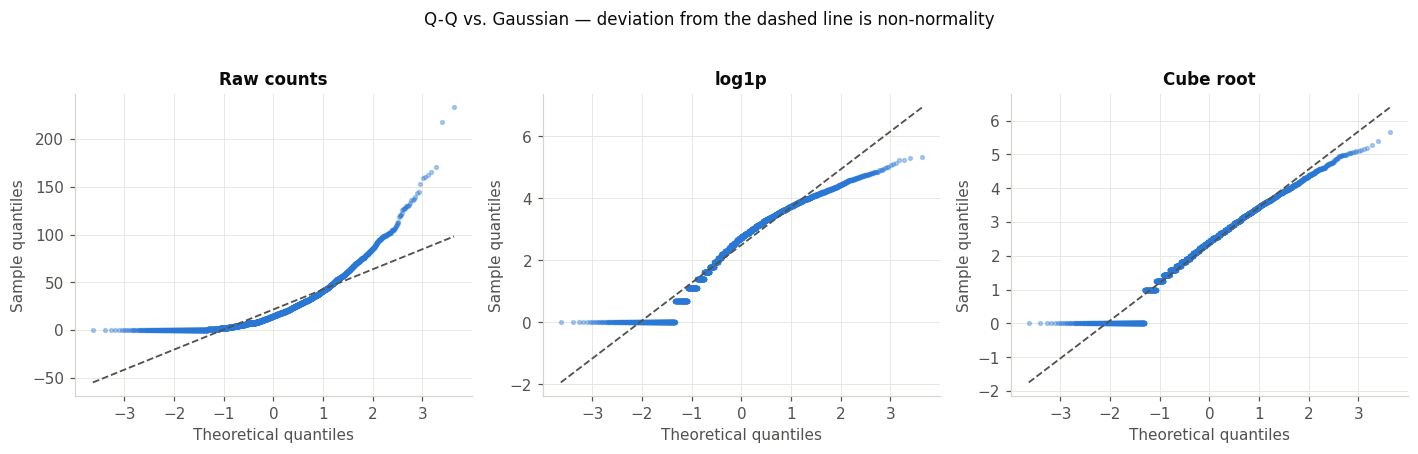

Raw: pronounced upward curve at the right tail = extreme positive skew.
log1p: over-corrects — the left tail bends below the line (skew turns negative).
cbrt: closest to the diagonal across the bulk of the distribution.


In [6]:
# Q-Q plots: the honest visual test. Points on the diagonal = Gaussian.
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)
for ax, (v, label) in zip(axes, [(x, "Raw counts"),
                                 (np.log1p(x), "log1p"),
                                 (np.cbrt(x), "Cube root")]):
    s = rng.choice(np.asarray(v, dtype=float), SUB, replace=False)
    stats.probplot(s, dist="norm", plot=ax)
    ax.get_lines()[0].set(marker="o", markersize=2.5, alpha=0.35,
                          color=BLUE, linestyle="none")
    ax.get_lines()[1].set(color=INK_SOFT, linewidth=1.2, linestyle="--")
    ax.set_title(label)
    ax.set_xlabel("Theoretical quantiles"); ax.set_ylabel("Sample quantiles")
fig.suptitle("Q-Q vs. Gaussian — deviation from the dashed line is non-normality",
             y=1.02, fontsize=11, color=INK)
plt.tight_layout(); plt.show()

print("Raw: pronounced upward curve at the right tail = extreme positive skew.")
print("log1p: over-corrects — the left tail bends below the line (skew turns negative).")
print("cbrt: closest to the diagonal across the bulk of the distribution.")

## 4 · Transformation benchmark

The project currently applies `log1p` (decision log, 2026-07-22). That decision was made by
comparing `log1p` against *raw only*. Here every practical candidate is compared on the same
footing, scored on both moments at once:

$$\text{score} = |\text{skew}| + \tfrac{1}{2}\,|\text{excess kurtosis}|$$

Candidates, all of which tolerate the zeros that make plain `log` unusable:

| Transform | Form | Notes |
|---|---|---|
| `log1p` | $\ln(1+x)$ | Strong compression; over-corrects when zeros are frequent |
| `sqrt` | $\sqrt{x}$ | Variance-stabilising for Poisson counts |
| `cbrt` | $x^{1/3}$ | Variance-stabilising for over-dispersed counts (Anscombe family) |
| `Yeo-Johnson` | power family | Fits λ from the data; handles zeros and negatives |

In [7]:
TRANSFORMS = {
    "raw":   lambda v: v,
    "log1p": np.log1p,
    "sqrt":  np.sqrt,
    "cbrt":  np.cbrt,
    "yeo-johnson": lambda v: stats.yeojohnson(v)[0],
}

rows = []
for c in COLS:
    v = df[c].astype(float).values
    for name, fn in TRANSFORMS.items():
        t = fn(v)
        rows.append({"variable": c, "transform": name,
                     "skew": stats.skew(t), "excess_kurtosis": stats.kurtosis(t)})
bench = pd.DataFrame(rows)
bench["score"] = bench["skew"].abs() + 0.5 * bench["excess_kurtosis"].abs()

print("=== SKEWNESS BY TRANSFORM ===")
display(bench.pivot(index="variable", columns="transform", values="skew").round(3))
print("=== EXCESS KURTOSIS BY TRANSFORM ===")
display(bench.pivot(index="variable", columns="transform", values="excess_kurtosis").round(3))

winner = bench.loc[bench.groupby("variable")["score"].idxmin()]
print("=== BEST TRANSFORM PER VARIABLE (lower score = closer to Gaussian) ===")
display(winner.set_index("variable")[["transform", "skew", "excess_kurtosis", "score"]].round(3))

=== SKEWNESS BY TRANSFORM ===


transform,cbrt,log1p,raw,sqrt,yeo-johnson
variable,,,,,
De_15_a_64,-0.335,-0.203,2.193,0.417,-0.032
De_1_a_4,-0.001,0.346,177.684,0.810,0.078
De_5_a_14,-0.032,0.272,2.917,0.639,0.068
De_65_y_mas,-0.073,0.428,3.144,0.428,0.111
Menores_1,0.628,1.210,45.662,1.418,0.384
Total_Respiratorias,-0.330,-0.515,6.345,0.403,-0.069


=== EXCESS KURTOSIS BY TRANSFORM ===


transform,cbrt,log1p,raw,sqrt,yeo-johnson
variable,,,,,
De_15_a_64,-0.414,-0.917,8.382,-0.067,-0.881
De_1_a_4,-0.854,-0.855,112139.908,4.388,-1.216
De_5_a_14,-0.999,-1.028,19.040,0.089,-1.252
De_65_y_mas,-1.354,-0.831,44.109,-0.431,-1.331
Menores_1,-0.646,1.090,14167.192,4.263,-1.534
Total_Respiratorias,-0.187,-0.587,821.996,0.179,-0.736


=== BEST TRANSFORM PER VARIABLE (lower score = closer to Gaussian) ===


,transform,skew,excess_kurtosis,score
variable,,,,
De_15_a_64,sqrt,0.417,-0.067,0.450
De_1_a_4,cbrt,-0.001,-0.854,0.428
De_5_a_14,cbrt,-0.032,-0.999,0.532
De_65_y_mas,sqrt,0.428,-0.431,0.643
Menores_1,cbrt,0.628,-0.646,0.951
Total_Respiratorias,cbrt,-0.330,-0.187,0.423


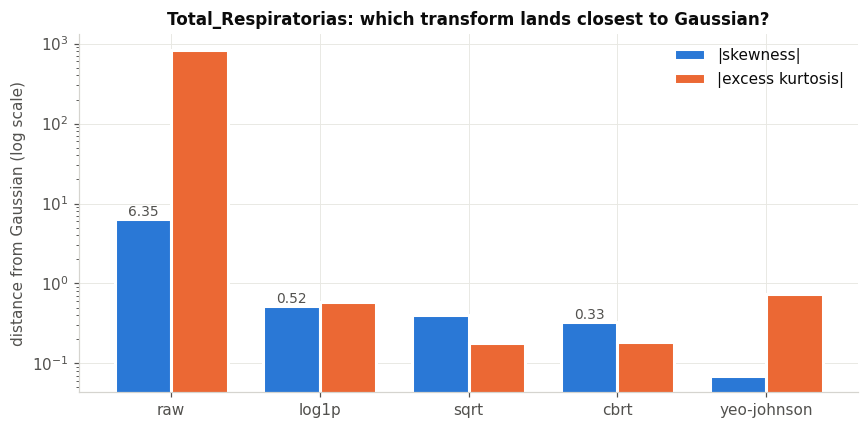

Winner for Total_Respiratorias: cbrt
               skew  excess_kurtosis     score
transform                                     
raw          6.3454         821.9962  417.3435
log1p       -0.5153          -0.5872    0.8089
sqrt         0.4028           0.1794    0.4925
cbrt        -0.3300          -0.1866    0.4233
yeo-johnson -0.0695          -0.7361    0.4375


In [8]:
# Head-to-head on the target: the number that decides the modelling contract.
t_scores = bench[bench.variable == TARGET].set_index("transform")
fig, ax = plt.subplots(figsize=(8, 4))
order = ["raw", "log1p", "sqrt", "cbrt", "yeo-johnson"]
xs = np.arange(len(order)); w = 0.38

ax.bar(xs - w/2, t_scores.loc[order, "skew"].abs(), w, label="|skewness|",
       color=BLUE, edgecolor="white", linewidth=2)
ax.bar(xs + w/2, t_scores.loc[order, "excess_kurtosis"].abs(), w, label="|excess kurtosis|",
       color=ORANGE, edgecolor="white", linewidth=2)
ax.set_yscale("log")   # raw kurtosis is 822 — linear scale would erase every other bar
ax.set_xticks(xs); ax.set_xticklabels(order)
ax.set_ylabel("distance from Gaussian (log scale)")
ax.set_title(f"{TARGET}: which transform lands closest to Gaussian?")
ax.legend(frameon=False)
for i, o in enumerate(order):                      # selective direct labels, not every bar
    if o in ("raw", "cbrt", "log1p"):
        ax.annotate(f"{abs(t_scores.loc[o,'skew']):.2f}", (i - w/2, abs(t_scores.loc[o,"skew"])),
                    ha="center", va="bottom", fontsize=9, color=INK_SOFT)
plt.tight_layout(); plt.show()

best = t_scores["score"].idxmin()
print(f"Winner for {TARGET}: {best}")
print(t_scores[["skew", "excess_kurtosis", "score"]].round(4).to_string())

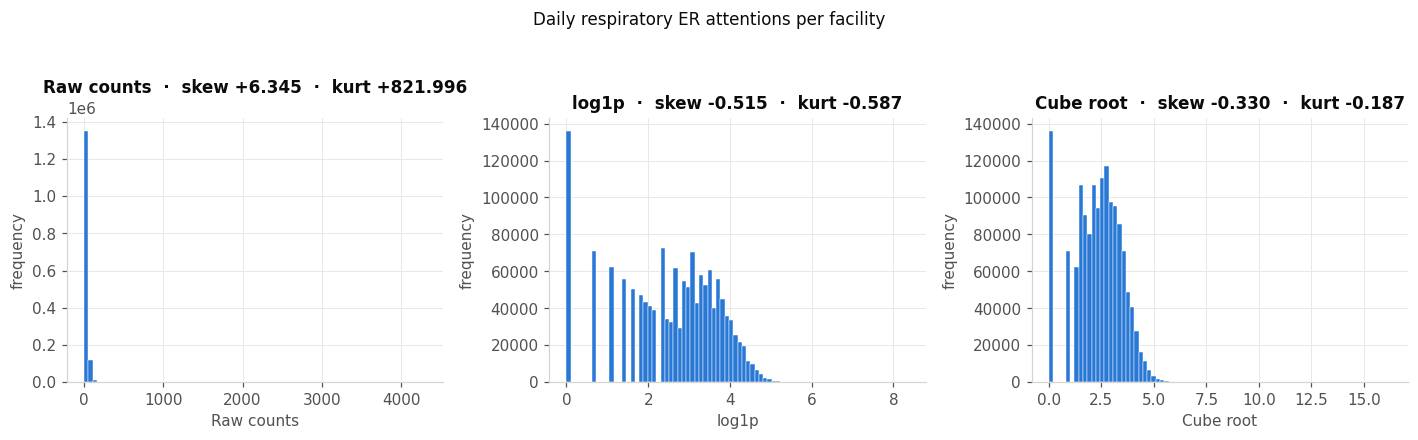

In [9]:
# Distribution, before and after — small multiples, one series each (no legend needed).
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, (v, label) in zip(axes, [(x, "Raw counts"),
                                 (np.log1p(x), "log1p"),
                                 (np.cbrt(x), "Cube root")]):
    ax.hist(v, bins=80, color=BLUE, edgecolor="white", linewidth=0.3)
    ax.set_title(f"{label}  ·  skew {stats.skew(v):+.3f}  ·  kurt {stats.kurtosis(v):+.3f}")
    ax.set_xlabel(label); ax.set_ylabel("frequency")
fig.suptitle("Daily respiratory ER attentions per facility", y=1.04, fontsize=11, color=INK)
plt.tight_layout(); plt.show()

## 5 · Correlation — Pearson vs. Spearman

Two coefficients, deliberately:

- **Pearson** measures *linear* association and is itself distorted by skew and outliers.
- **Spearman** is rank-based, so it survives monotone non-linearity and heavy tails.

When Spearman is consistently **higher** than Pearson, the relationships are monotone but
curved — further evidence that the variables should enter a model transformed.

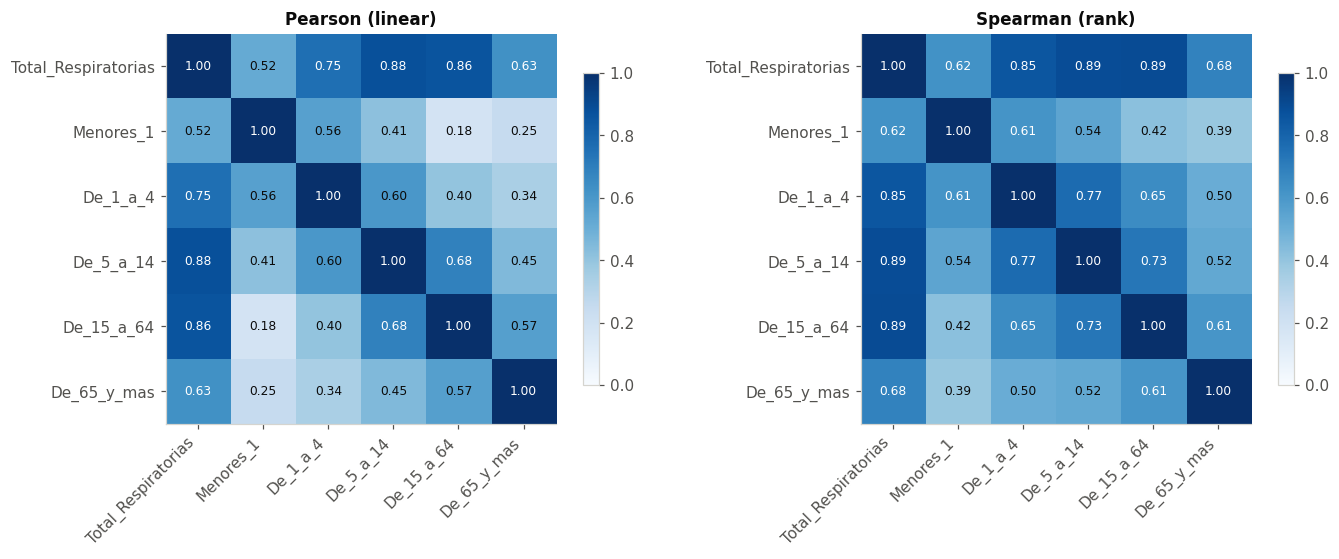

Spearman − Pearson: mean gap +0.107, max +0.246
Positive throughout → monotone but non-linear relationships.


In [10]:
pearson = df[COLS].corr()
spearman = df[COLS].corr("spearman")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, m, name in [(axes[0], pearson, "Pearson (linear)"),
                    (axes[1], spearman, "Spearman (rank)")]:
    # All coefficients here are positive → sequential, single hue, light→dark.
    im = ax.imshow(m, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(COLS))); ax.set_xticklabels(COLS, rotation=45, ha="right")
    ax.set_yticks(range(len(COLS))); ax.set_yticklabels(COLS)
    ax.set_title(name); ax.grid(False)
    for i in range(len(COLS)):
        for j in range(len(COLS)):
            val = m.iloc[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8,
                    color="white" if val > 0.6 else INK)   # ink tokens, never the series hue
    fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

gap = (spearman - pearson).where(~np.eye(len(COLS), dtype=bool))
print(f"Spearman − Pearson: mean gap {gap.stack().mean():+.3f}, max {gap.stack().max():+.3f}")
print("Positive throughout → monotone but non-linear relationships.")

## 6 · Multicollinearity — VIF

The **Variance Inflation Factor** quantifies how much a predictor is explained by the
others: $\mathrm{VIF}_i = 1/(1-R_i^2)$, where $R_i^2$ comes from regressing feature *i* on
the rest. VIF = 1 means independent; > 5 is concerning; > 10 is severe; **∞ means an exact
linear dependency**.

§1 already proved the fatal case: the five age groups sum to `Total_Respiratorias` in
**every single row**. That is not a correlation — it is an accounting identity, and it makes
any attribution over that feature set undefined.

In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def vif_table(frame, cols):
    X = frame[cols].astype(float).assign(_const=1.0)
    return pd.Series(
        {c: variance_inflation_factor(X.values, i) for i, c in enumerate(X.columns)}
    ).drop("_const").sort_values(ascending=False)

print("=== A · total + age groups (the identity is present) ===")
print(vif_table(df, COLS).round(2).to_string())
print("\n=== B · age groups only (identity removed) ===")
print(vif_table(df, AGE_COLS).round(2).to_string())

print('''
Reading it
  A: every VIF is infinite. Total = SUM(age groups) is exact, so each column is
     perfectly predictable from the others. Feeding this set to any model (TFT
     included) makes feature importance arbitrary: the model can shift weight
     between collinear inputs with no change in fit.
  B: with the total dropped, every VIF sits between 1.5 and 2.6 - comfortably
     below the concern threshold of 5. The age groups are usable together.

Contract: model EITHER the total OR the age-group decomposition. Never both.
''')

=== A · total + age groups (the identity is present) ===


Total_Respiratorias    inf
Menores_1              inf
De_1_a_4               inf
De_5_a_14              inf
De_15_a_64             inf
De_65_y_mas            inf

=== B · age groups only (identity removed) ===


De_5_a_14      2.56
De_15_a_64     2.33
De_1_a_4       1.92
Menores_1      1.54
De_65_y_mas    1.52

Reading it
  A: every VIF is infinite. Total = SUM(age groups) is exact, so each column is
     perfectly predictable from the others. Feeding this set to any model (TFT
     included) makes feature importance arbitrary: the model can shift weight
     between collinear inputs with no change in fit.
  B: with the total dropped, every VIF sits between 1.5 and 2.6 - comfortably
     below the concern threshold of 5. The age groups are usable together.

Contract: model EITHER the total OR the age-group decomposition. Never both.



## 7 · Conclusions — the contract for HDBSCAN and the TFT

**Target definition.** `IdCausa = 2` only. The previous `LIKE '%RESPIRATORIO%'` predicate
also captured `IdCausa = 7` (hospitalizations, SECCIÓN 2), inflating the target ~1.7% and
mixing two clinical events. Import `load_target()`; do not re-write the query.

**Transformation.** The cube root beats `log1p` on the target on both moments
(skew −0.33 vs −0.52; excess kurtosis −0.19 vs −0.59), and wins or ties for the age groups
too. `log1p` over-corrects: it turns a strong right skew into a visible left skew, which the
Q-Q plot in §3 shows directly. Recommendation: switch the modelling transform to `cbrt`,
inverted at serving time by cubing. This supersedes the 2026-07-22 decision — which was
sound given that it only compared against raw.

**Feature-set constraint.** Never combine `Total_Respiratorias` with the five age groups:
they are related by an exact identity (VIF = ∞). Pick one representation.

**Panel structure.** 817 facilities × 2,922 days, but only 62% of cells observed and the
bottom 5% of facilities report fewer than 367 days. A TFT needs either a minimum-history
filter or explicit masking — an unreported day is not a zero-demand day, and treating it as
one teaches the model a fiction.

**Exogenous coverage is the binding constraint.** Only 734 of 817 facilities map to a
station at all, and SINCA processed data covers 2023-2025 against a target spanning
2017-2024 — a real overlap of roughly two years. Decide explicitly whether the TFT trains
on 8 years without pollution features or 2 years with them.

**For HDBSCAN specifically.** Cluster on transformed, standardised features; raw counts with
excess kurtosis in the hundreds will place every outlier hospital in its own singleton
cluster. Restrict the input to facilities whose station distance is credible — the mapping
table currently contains a 3,509 km "nearest" neighbour.

---

## Appendix · Automated profiling reports

The profilers below produce the broad descriptive sweep. They are complementary to — not a
substitute for — the targeted tests above: they report skewness, but they do not compare
transformations, test multicollinearity, or check an accounting identity.

In [1]:
import duckdb, sweetviz as sv
from ydata_profiling import ProfileReport

# The profilers load everything into RAM, so they are fed the aggregated panel only.
df_eda = df.copy()
print(f"Profiling {len(df_eda):,} aggregated rows (raw records stay on disk).")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_3304\1644396270.py:2: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


NameError: name 'df' is not defined

### 1. Sweetviz Profiling
Sweetviz creates highly visual and comparative HTML reports.

In [ ]:
print("\n=== GENERATING SWEETVIZ REPORT ===")
sv_report = sv.analyze(df_eda)
sv_report.show_html('Sweetviz_EDA_Report.html', open_browser=False)
print("Sweetviz report successfully saved to 'Sweetviz_EDA_Report.html'")

### 2. YData Profiling
Generates a comprehensive standardized statistical report.

In [ ]:
print("\n=== GENERATING YDATA-PROFILING REPORT ===")
profile = ProfileReport(df_eda, title="Respiratory Urgencies Profiling Report", explorative=True, minimal=True)
profile.to_file("YData_EDA_Report.html")
print("YData Profiling report successfully saved to 'YData_EDA_Report.html'")

### 3. D-Tale Interactive Exploration
Uncomment and run the cell below in your local Jupyter environment to launch the D-Tale GUI.

In [ ]:
d = dtale.show(df_eda)
d.open_browser()